# Procjena duljine boravka hotelskih gostiju

**Kolegij:** Uvod u podatkovnu znanost  
**Dataset:** Hotel Booking Demand Dataset (Kaggle – `hotel_bookings.csv`)  
**Cilj:** Izgraditi regresijski i klasifikacijski model koji predviđa duljinu boravka hotelskih gostiju na temelju dostupnih obilježja rezervacije.

---

## 0. Uvoz biblioteka

Uvozimo sve potrebne biblioteke na jednom mjestu kako bi notebook bio pregledan i kako bismo izbjegli višestruke uvozne naredbe unutar koda.

In [3]:
%matplotlib inline

# Osnovna analiza podataka
import pandas as pd
import numpy as np

# Vizualizacija
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Predprocesiranje
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve

# Modeli
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# Evaluacija
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, classification_report, accuracy_score
)

# Ostalo
import time
import warnings
warnings.filterwarnings('ignore')

# Postavi globalni stil grafova
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('Sve biblioteke uspješno učitane!')

Sve biblioteke uspješno učitane!


---
## 1. Učitavanje i pregled podataka

Učitavamo dataset iz CSV datoteke i provodimo inicijalni pregled: oblik tablice, prvih nekoliko redaka, tipove stupaca, opisnu statistiku i broj nedostajućih vrijednosti. Ovaj korak nam daje uvid u kvalitetu i strukturu podataka prije bilo kakve obrade.

In [4]:
# Učitavanje dataseta
df = pd.read_csv('hotel_bookings.csv')

print(f'Oblik dataseta: {df.shape[0]:,} redaka × {df.shape[1]} stupaca')

Oblik dataseta: 119,390 redaka × 32 stupaca


In [3]:
# Prikaz prvih 5 redaka
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [5]:
# Informacije o tipu podataka i popunjenosti stupaca
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [6]:
# Opisna statistika numeričkih stupaca
df.describe().round(2)

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119386.0,119390.00,119390.00,119390.00,119390.00,119390.00,103050.00,6797.00,119390.00,119390.00,119390.00,119390.00
mean,0.37,104.01,2016.16,27.17,15.80,0.93,2.50,1.86,0.1,0.01,0.03,0.09,0.14,0.22,86.69,189.27,2.32,101.83,0.06,0.57
std,0.48,106.86,0.71,13.61,8.78,1.00,1.91,0.58,0.4,0.10,0.18,0.84,1.50,0.65,110.77,131.66,17.59,50.54,0.25,0.79
min,0.00,0.00,2015.00,1.00,1.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,1.00,6.00,0.00,-6.38,0.00,0.00
25%,0.00,18.00,2016.00,16.00,8.00,0.00,1.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,9.00,62.00,0.00,69.29,0.00,0.00
50%,0.00,69.00,2016.00,28.00,16.00,1.00,2.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,14.00,179.00,0.00,94.58,0.00,0.00
75%,1.00,160.00,2017.00,38.00,23.00,2.00,3.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,229.00,270.00,0.00,126.00,0.00,1.00
max,1.00,737.00,2017.00,53.00,31.00,19.00,50.00,55.00,10.0,10.00,1.00,26.00,72.00,21.00,535.00,543.00,391.00,5400.00,8.00,5.00


In [7]:
# Broj i postotak nedostajućih vrijednosti po stupcu
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Nedostaje (n)': missing, 'Nedostaje (%)': missing_pct})
missing_df = missing_df[missing_df['Nedostaje (n)'] > 0].sort_values('Nedostaje (n)', ascending=False)
print('Stupci s nedostajućim vrijednostima:')
missing_df

Stupci s nedostajućim vrijednostima:


,Nedostaje (n),Nedostaje (%)
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


**Zaključak – Sekcija 1:**  
Dataset sadrži 119 390 rezervacija i 32 stupca. Identificirali smo stupce s nedostajućim vrijednostima: `company` ima najveći udio (~94 %), `agent` (~14 %), `country` (~0.4 %) i `children` (~0.003 %). Te ćemo vrijednosti obraditi u koraku pretprocesiranja.

---
## 2. Kreiranje ciljne varijable

Ciljna varijabla `length_of_stay` dobiva se zbrajanjem noćenja vikendom i noćenja radnim danom. Rezervacije s nultom duljinom boravka (npr. otkazane ili pogrešne rezervacije) uklanjamo jer ne pružaju korisnu informaciju za modeliranje.

In [8]:
# Kreiraj ciljnu varijablu kao zbroj vikend i tjednih noćenja
df['length_of_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# Broj zapisa s nultim boravkom
zero_stays = (df['length_of_stay'] == 0).sum()
print(f'Zapisi s length_of_stay == 0: {zero_stays:,}')

# Ukloni zapise s nultim boravkom
df = df[df['length_of_stay'] > 0].reset_index(drop=True)
print(f'Dataset nakon uklanjanja: {df.shape[0]:,} redaka')

Zapisi s length_of_stay == 0: 715
Dataset nakon uklanjanja: 118,675 redaka


In [9]:
# Osnovna statistika ciljne varijable
stats = df['length_of_stay'].describe()
print('Statistika ciljne varijable length_of_stay:')
print(f'  Mean   : {stats["mean"]:.2f} noćenja')
print(f'  Median : {df["length_of_stay"].median():.0f} noćenja')
print(f'  Std    : {stats["std"]:.2f}')
print(f'  Min    : {stats["min"]:.0f}')
print(f'  Max    : {stats["max"]:.0f}')

Statistika ciljne varijable length_of_stay:
  Mean   : 3.45 noćenja
  Median : 3 noćenja
  Std    : 2.55
  Min    : 1
  Max    : 69


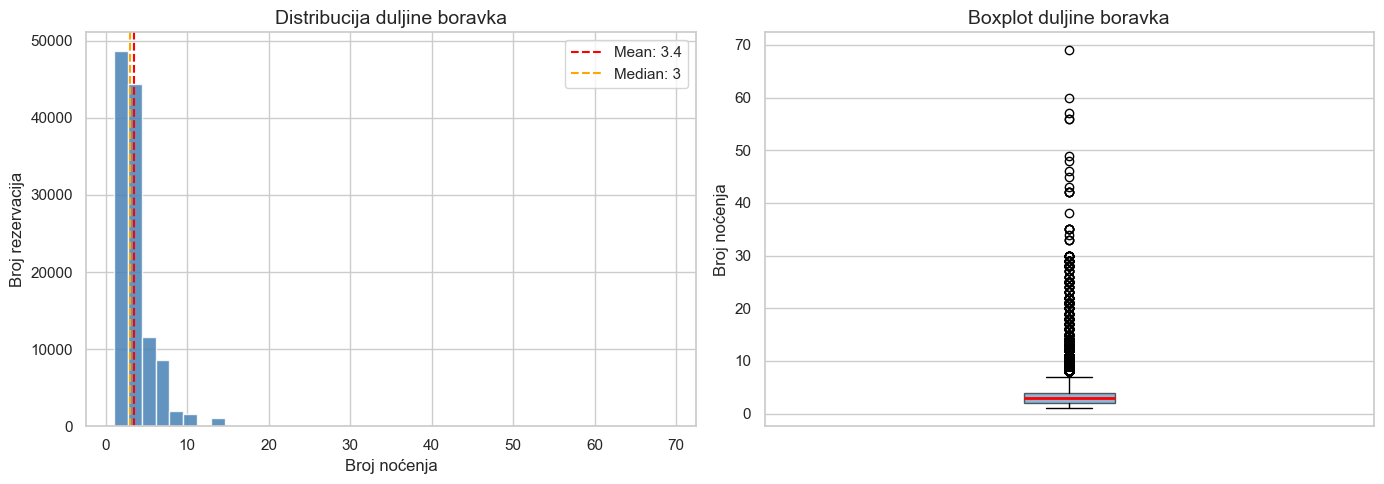

In [11]:
# Vizualizacija distribucije ciljne varijable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['length_of_stay'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribucija duljine boravka', fontsize=14)
axes[0].set_xlabel('Broj noćenja')
axes[0].set_ylabel('Broj rezervacija')
axes[0].axvline(df['length_of_stay'].mean(), color='red', linestyle='--', label=f'Mean: {df["length_of_stay"].mean():.1f}')
axes[0].axvline(df['length_of_stay'].median(), color='orange', linestyle='--', label=f'Median: {df["length_of_stay"].median():.0f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['length_of_stay'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot duljine boravka', fontsize=14)
axes[1].set_ylabel('Broj noćenja')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

**Zaključak – Sekcija 2:**  
Distribucija `length_of_stay` je desno asimetrična – većina gostiju boravi 2–5 noćenja, ali postoje i ekstremni outlieri (visoke vrijednosti). Srednja vrijednost je viša od medijana, što potvrđuje asimetričnost. Outlierse ćemo obraditi u sekciji 4 metodom IQR.

---
## 3. Eksploratorna analiza podataka (EDA)

EDA nam pomaže razumjeti odnose između varijabli, identificirati obrasce i donijeti informirane odluke o odabiru značajki za model.

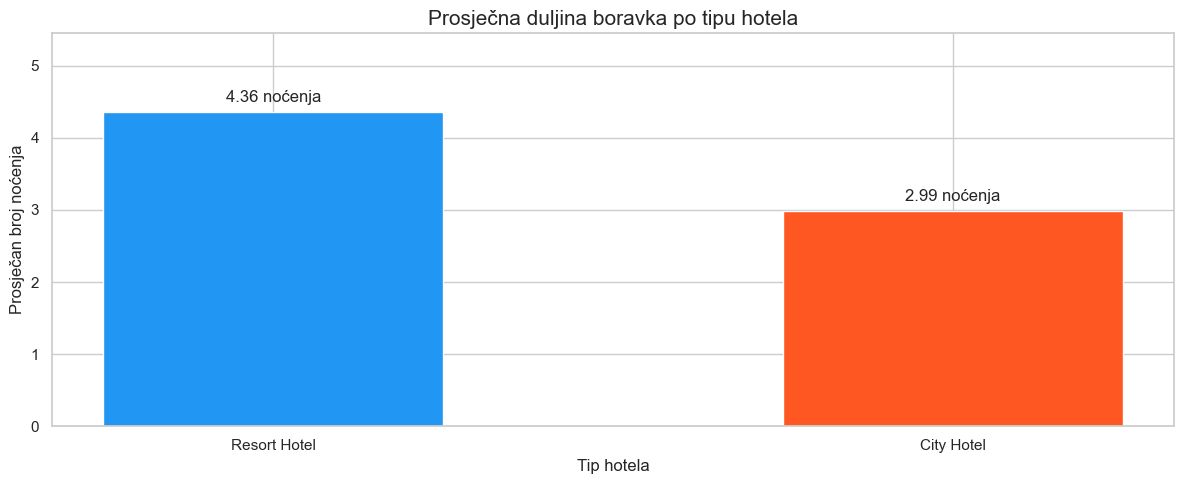

In [12]:
# --- Prosječna duljina boravka po tipu hotela ---
avg_hotel = df.groupby('hotel')['length_of_stay'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(avg_hotel.index, avg_hotel.values, color=['#2196F3', '#FF5722'], edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='%.2f noćenja', padding=5, fontsize=12)
ax.set_title('Prosječna duljina boravka po tipu hotela', fontsize=15)
ax.set_xlabel('Tip hotela')
ax.set_ylabel('Prosječan broj noćenja')
ax.set_ylim(0, avg_hotel.max() * 1.25)
plt.tight_layout()
plt.show()

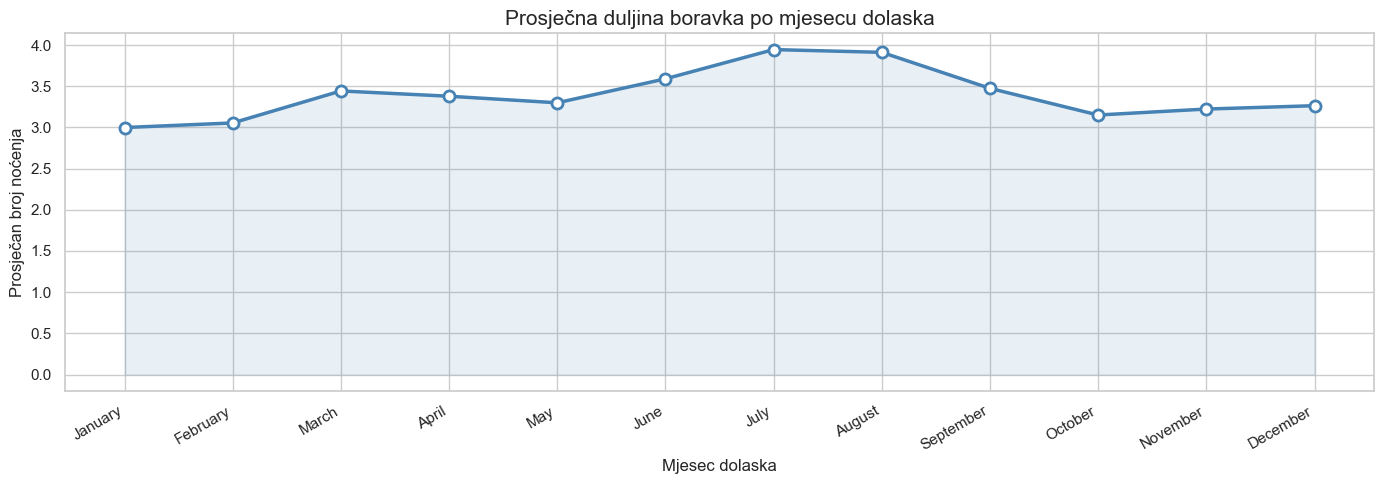

In [13]:
# --- Prosječna duljina boravka po mjesecu dolaska ---
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
avg_month = df.groupby('arrival_date_month')['length_of_stay'].mean().reindex(month_order)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(avg_month.index, avg_month.values, marker='o', linewidth=2.5,
        color='steelblue', markersize=8, markerfacecolor='white', markeredgewidth=2)
ax.fill_between(range(len(avg_month)), avg_month.values, alpha=0.12, color='steelblue')
ax.set_xticks(range(len(avg_month)))
ax.set_xticklabels(avg_month.index, rotation=30, ha='right')
ax.set_title('Prosječna duljina boravka po mjesecu dolaska', fontsize=15)
ax.set_xlabel('Mjesec dolaska')
ax.set_ylabel('Prosječan broj noćenja')
plt.tight_layout()
plt.show()

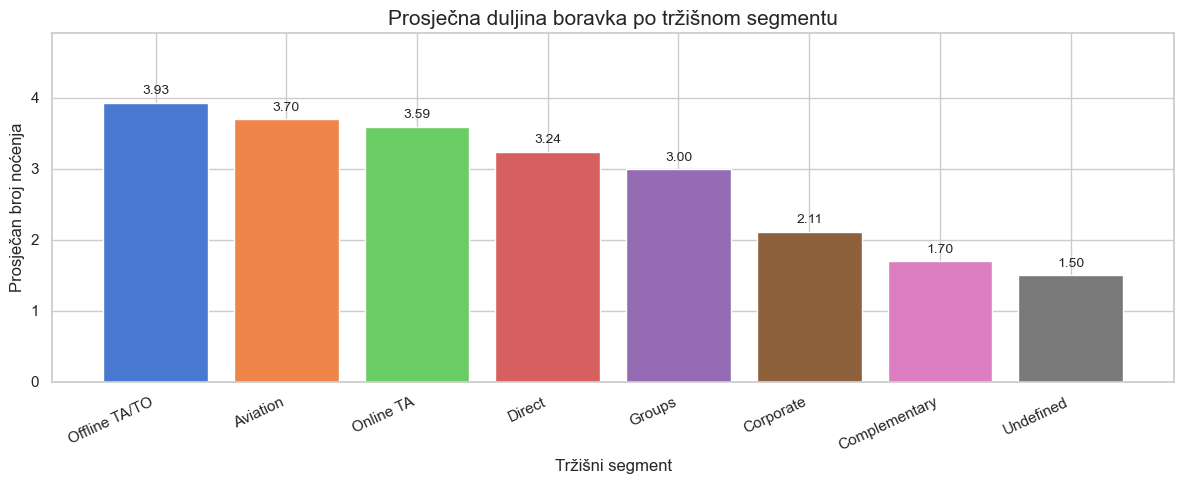

In [14]:
# --- Prosječna duljina boravka po market_segment ---
avg_segment = df.groupby('market_segment')['length_of_stay'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(avg_segment.index, avg_segment.values,
              color=sns.color_palette('muted', len(avg_segment)), edgecolor='white')
ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=10)
ax.set_title('Prosječna duljina boravka po tržišnom segmentu', fontsize=15)
ax.set_xlabel('Tržišni segment')
ax.set_ylabel('Prosječan broj noćenja')
ax.set_ylim(0, avg_segment.max() * 1.25)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

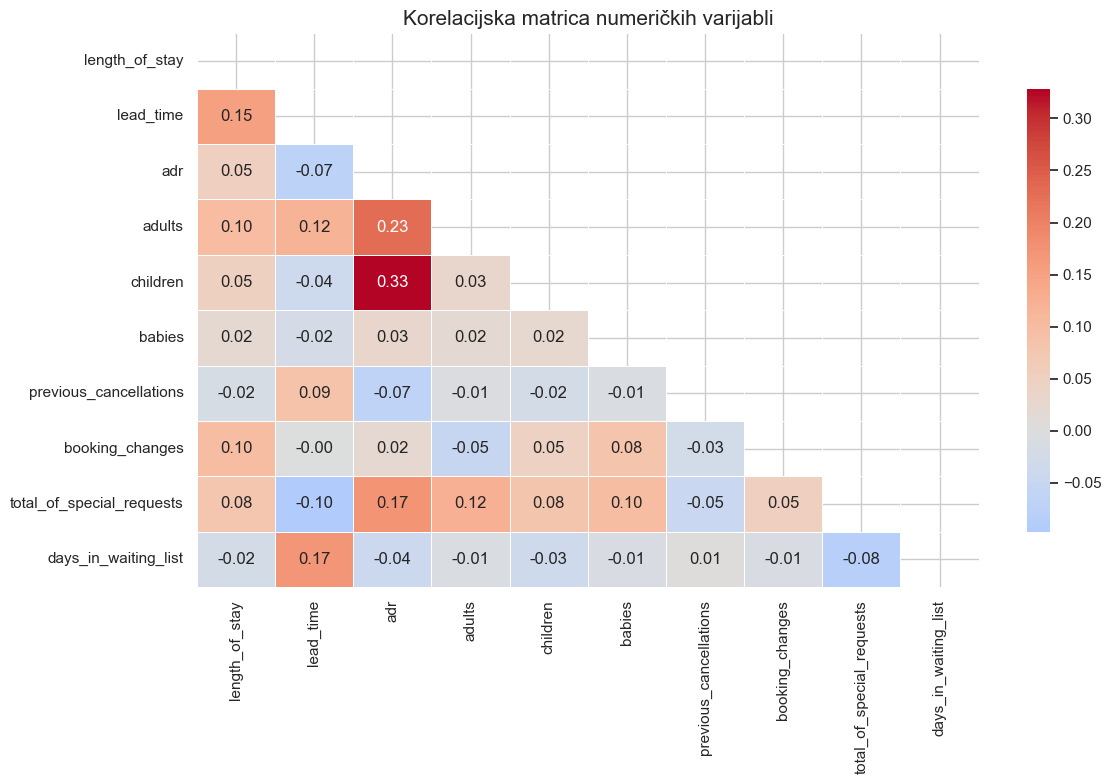

In [15]:
# --- Korelacijska matrica numeričkih varijabli ---
num_cols = [
    'length_of_stay', 'lead_time', 'adr', 'adults', 'children',
    'babies', 'previous_cancellations', 'booking_changes',
    'total_of_special_requests', 'days_in_waiting_list'
]
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Korelacijska matrica numeričkih varijabli', fontsize=15)
plt.tight_layout()
plt.show()

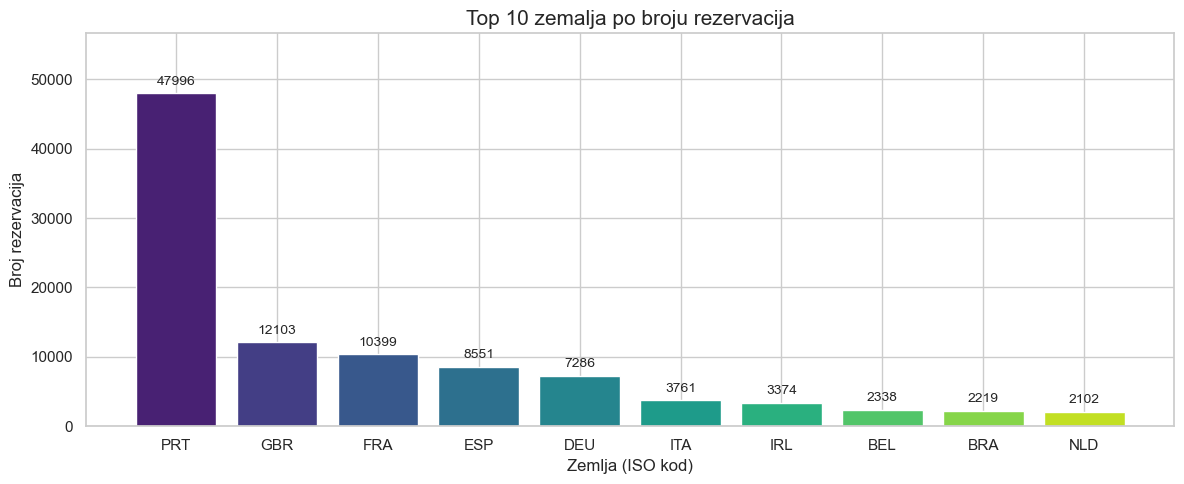

In [14]:
# --- Top 10 zemalja po broju rezervacija ---
top10_countries = df['country'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(top10_countries.index, top10_countries.values,
              color=sns.color_palette('viridis', 10), edgecolor='white')
ax.bar_label(bars, fmt='%d', padding=4, fontsize=10)
ax.set_title('Top 10 zemalja po broju rezervacija', fontsize=15)
ax.set_xlabel('Zemlja (ISO kod)')
ax.set_ylabel('Broj rezervacija')
ax.set_ylim(0, top10_countries.max() * 1.18)
plt.tight_layout()
plt.show()

**Zaključak – Sekcija 3:**  
- **Resort hoteli** imaju znatno dulje prosječne boravke od gradskih hotela, što je očekivano jer gosti dolaze na odmor.  
- **Ljetni mjeseci** (srpanj–kolovoz) bilježe dulje boravke, dok je zima period kraćih posjeta.  
- **Direct i Corporate segmenti** bilježe kraće boravke, dok **Groups i Complementary** prednjače u duljem boravku.  
- Korelacije između numeričkih varijabli i ciljne varijable su umjerene – `lead_time` i `adr` imaju blag pozitivan utjecaj.  
- **Portugal (PRT)** je daleko najzastupljenija zemlja, što ukazuje na lokalni fokus dataseta.

---
## 4. Pretprocesiranje podataka

U ovom koraku čistimo podatke, kodiramo kategorijske varijable i pripremamo train/test skupove za modeliranje. Kvalitetno pretprocesiranje ključno je za performanse modela.

In [16]:
# 1. Ukloni duplikate
before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Uklonjeno duplikata: {before - len(df):,} | Preostalo redaka: {len(df):,}')

Uklonjeno duplikata: 31,930 | Preostalo redaka: 86,745


In [17]:
# 2. Obrada nedostajućih vrijednosti
df['children'].fillna(0, inplace=True)          # djeca → 0 (pretpostavljamo bez djece)
df['country'].fillna('Unknown', inplace=True)    # nepoznata zemlja → 'Unknown'
df['agent'].fillna(0, inplace=True)             # bez agenta → 0
df.drop(columns=['company'], inplace=True)       # company → uklanjamo (~94% null)

# Provjera
remaining_null = df.isnull().sum().sum()
print(f'Ukupno preostalih null vrijednosti: {remaining_null}')

Ukupno preostalih null vrijednosti: 0


In [18]:
# 3. Detekcija i uklanjanje outliera metodom IQR + gornji prag od 30 noćenja
Q1 = df['length_of_stay'].quantile(0.25)
Q3 = df['length_of_stay'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(f'Q1={Q1}, Q3={Q3}, IQR={IQR}')
print(f'Gornja granica IQR: {upper_bound:.1f} noćenja')
print(f'Primijenjeni prag:  30 noćenja (domensko ograničenje)')

before = len(df)
df = df[df['length_of_stay'] <= 30].reset_index(drop=True)
print(f'Uklonjeno outliera: {before - len(df):,} | Preostalo: {len(df):,}')

Q1=2.0, Q3=5.0, IQR=3.0
Gornja granica IQR: 9.5 noćenja
Primijenjeni prag:  30 noćenja (domensko ograničenje)
Uklonjeno outliera: 23 | Preostalo: 86,722


In [19]:
# 4. One-Hot Encoding za nominalne kategorijske varijable
ohe_cols = ['hotel', 'meal', 'market_segment', 'distribution_channel', 'customer_type']
df = pd.get_dummies(df, columns=ohe_cols, drop_first=False)
print(f'Shape nakon OHE: {df.shape}')

Shape nakon OHE: (86722, 51)


In [20]:
# 5. Label Encoding za ordinalne/visokokardinalne kategorijske varijable
le = LabelEncoder()
label_cols = ['country', 'reserved_room_type', 'assigned_room_type']
for col in label_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    
print('Label encoding primijenjen na:', label_cols)

Label encoding primijenjen na: ['country', 'reserved_room_type', 'assigned_room_type']


In [21]:
# 6. Definiraj features (X) i ciljnu varijablu (y)
# Uklanjamo stupce koji ne bi bili dostupni kod stvarne predikcije ili su izravno vezani za target
drop_cols = [
    'length_of_stay',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'arrival_date_month',       # string, koristimo numeričke verzije
    'arrival_date_year',
    'arrival_date_week_number',
    'arrival_date_day_of_month',
    'reservation_status',       # data leakage
    'reservation_status_date',  # data leakage
]
drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols)
y = df['length_of_stay']

# Pretvori bool stupce u int (OHE rezultati)
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

print(f'Features (X): {X.shape[1]} stupaca, {X.shape[0]:,} redaka')
print(f'Target (y):   distribucija → mean={y.mean():.2f}, median={y.median():.0f}')

Features (X): 42 stupaca, 86,722 redaka
Target (y):   distribucija → mean=3.65, median=3


In [22]:
# 7. Train/test split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f'Train skup: {X_train.shape[0]:,} redaka')
print(f'Test skup:  {X_test.shape[0]:,} redaka')

Train skup: 69,377 redaka
Test skup:  17,345 redaka


In [33]:
# 8. StandardScaler normalizacija

X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Normalizacija završena. Primjer – mean prvog stupca (train):', 
      round(X_train_scaled[:, 0].mean(), 4))

Normalizacija završena. Primjer – mean prvog stupca (train): 0.0


**Zaključak – Sekcija 4:**  
Podaci su očišćeni: uklonili smo duplikate, popunili nedostajuće vrijednosti domenski smislenim vrijednostima, uklonili stupac `company` zbog nedostatka podataka i izbacili outliere iznad 30 noćenja. Kodiranjem i normalizacijom podaci su spremni za ulaz u model.

---
## 5. Modeliranje – Random Forest Regressor

Koristimo **Random Forest Regressor** – ansambl metodu koja gradi više stabala odluke i agregira njihove predikcije. Odabrana je zbog robusnosti na outliere, sposobnosti hvatanja nelinearnih odnosa i ugrađene procjene važnosti značajki.

In [34]:
# Inicijalizacija i treniranje Random Forest Regressora
rf_reg = RandomForestRegressor(
    n_estimators=200,       # broj stabala
    max_depth=15,           # maksimalna dubina stabla
    min_samples_split=5,    # minimalan broj uzoraka za podjelu čvora
    min_samples_leaf=2,     # minimalan broj uzoraka u listu
    random_state=42,
    n_jobs=-1               # paralelno na svim procesorskim jezgrama
)

start = time.time()
rf_reg.fit(X_train_scaled, y_train)
elapsed = time.time() - start

print(f'Treniranje završeno za {elapsed:.1f} sekundi.')

Treniranje završeno za 5.3 sekundi.


**Zaključak – Sekcija 5:**  
Model je uspješno istreniran. Random Forest s 200 stabala gradi robustnu predikcijsku funkciju koja integrira doprinose svakog stabla. Sljedeći korak je evaluacija kvalitete modela na test skupu.

---
## 6. Evaluacija regresijskog modela

Evaluiramo model na temelju standardnih metrika: MAE (srednja apsolutna greška), MSE, RMSE i R² koeficijent determinacije. Prikazujemo i vizualizacije koje otkrivaju obrasce u greškama modela.

In [35]:
# Predikcije na train i test skupu
y_train_pred = rf_reg.predict(X_train_scaled)
y_pred       = rf_reg.predict(X_test_scaled)

# Izračun metrika
def compute_metrics(y_true, y_pred_vals):
    mae  = mean_absolute_error(y_true, y_pred_vals)
    mse  = mean_squared_error(y_true, y_pred_vals)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred_vals)
    return mae, mse, rmse, r2

train_mae, train_mse, train_rmse, train_r2 = compute_metrics(y_train, y_train_pred)
test_mae,  test_mse,  test_rmse,  test_r2  = compute_metrics(y_test,  y_pred)

# Prikaz u tablici
metrics_df = pd.DataFrame({
    'Metrika': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Train':   [round(train_mae,4), round(train_mse,4), round(train_rmse,4), round(train_r2,4)],
    'Test':    [round(test_mae,4),  round(test_mse,4),  round(test_rmse,4),  round(test_r2,4)]
})
print('=== Evaluacijske metrike ===' )
metrics_df

=== Evaluacijske metrike ===


,Metrika,Train,Test
0,MAE,1.1318,1.3412
1,MSE,2.7190,4.1708
2,RMSE,1.6489,2.0422
3,R²,0.6149,0.4409


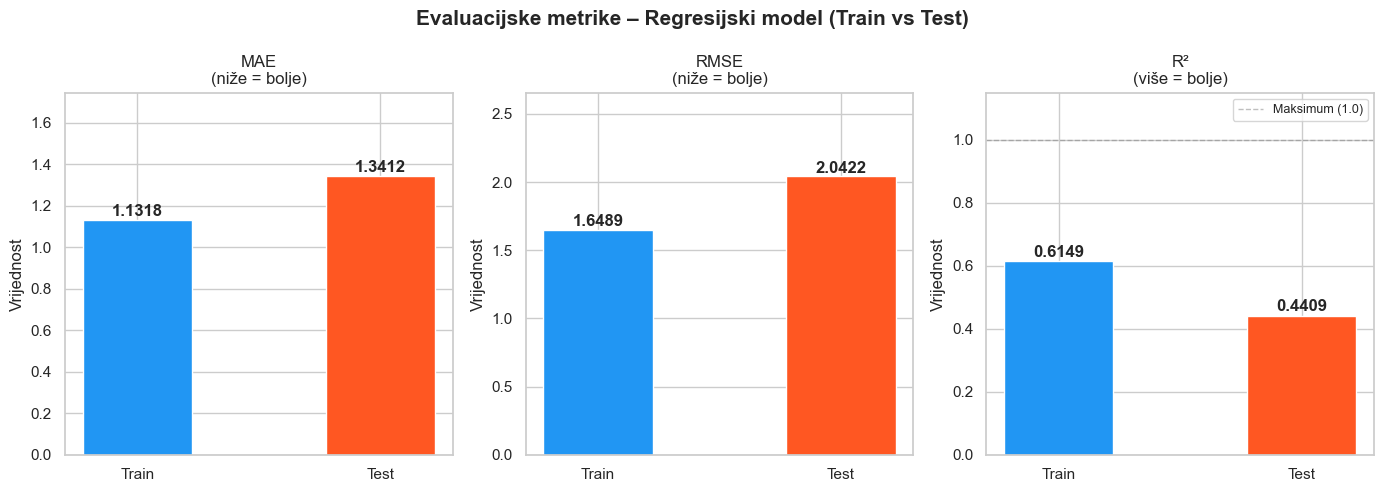

In [36]:

# Vizualizacija evaluacijskih metrika – Train vs Test usporedba
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Evaluacijske metrike – Regresijski model (Train vs Test)', fontsize=15, fontweight='bold')

labels = ['Train', 'Test']
colors = ['#2196F3', '#FF5722']

# MAE
axes[0].bar(labels, [train_mae, test_mae], color=colors, edgecolor='white', width=0.45)
for i, v in enumerate([train_mae, test_mae]):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_title('MAE\n(niže = bolje)', fontsize=12)
axes[0].set_ylabel('Vrijednost')
axes[0].set_ylim(0, max(train_mae, test_mae) * 1.3)

# RMSE
axes[1].bar(labels, [train_rmse, test_rmse], color=colors, edgecolor='white', width=0.45)
for i, v in enumerate([train_rmse, test_rmse]):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[1].set_title('RMSE\n(niže = bolje)', fontsize=12)
axes[1].set_ylabel('Vrijednost')
axes[1].set_ylim(0, max(train_rmse, test_rmse) * 1.3)

# R²
axes[2].bar(labels, [train_r2, test_r2], color=colors, edgecolor='white', width=0.45)
for i, v in enumerate([train_r2, test_r2]):
    axes[2].text(i, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[2].set_title('R²\n(više = bolje)', fontsize=12)
axes[2].set_ylabel('Vrijednost')
axes[2].set_ylim(0, 1.15)
axes[2].axhline(1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Maksimum (1.0)')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()


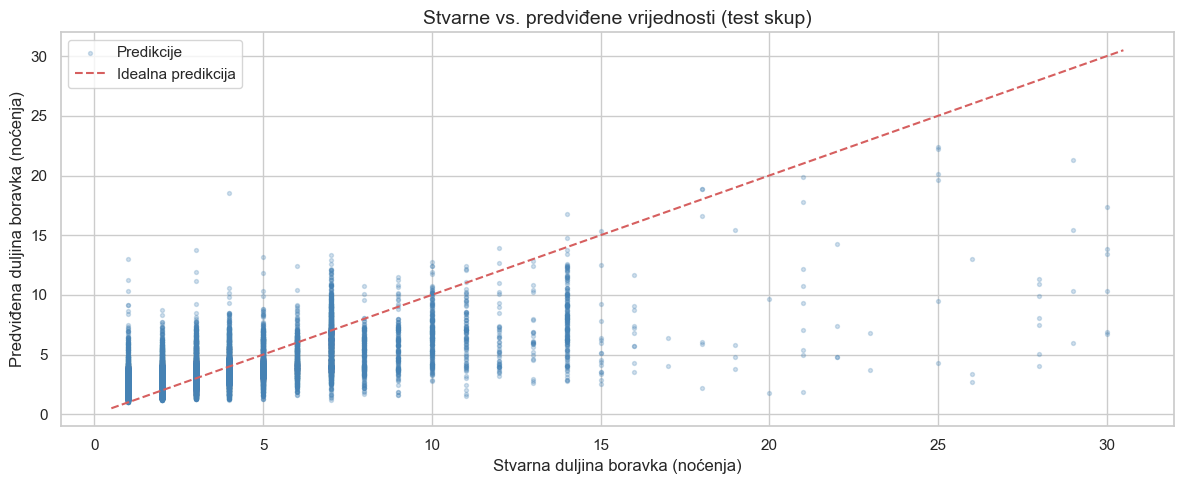

In [37]:
# Scatter plot: stvarne vs. predviđene vrijednosti (test skup)
fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(y_test, y_pred, alpha=0.25, s=8, color='steelblue', label='Predikcije')
lims = [min(y_test.min(), y_pred.min()) - 0.5, max(y_test.max(), y_pred.max()) + 0.5]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Idealna predikcija')
ax.set_title('Stvarne vs. predviđene vrijednosti (test skup)', fontsize=14)
ax.set_xlabel('Stvarna duljina boravka (noćenja)')
ax.set_ylabel('Predviđena duljina boravka (noćenja)')
ax.legend()
plt.tight_layout()
plt.show()

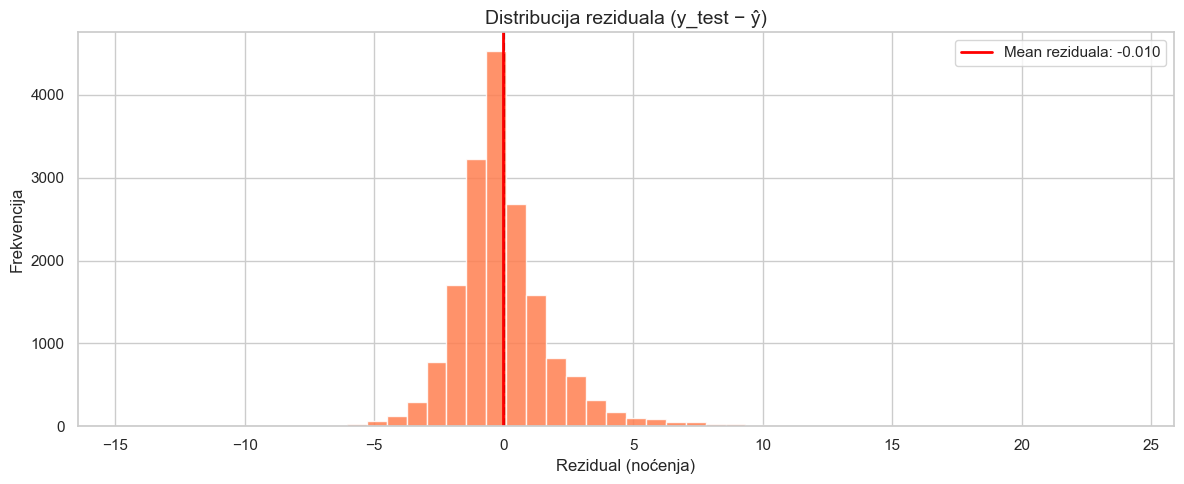

In [38]:
# Histogram reziduala
residuals = y_test.values - y_pred

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(residuals, bins=50, color='coral', edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linestyle='--', linewidth=1.5)
ax.axvline(residuals.mean(), color='red', linestyle='-', linewidth=2,
           label=f'Mean reziduala: {residuals.mean():.3f}')
ax.set_title('Distribucija reziduala (y_test − ŷ)', fontsize=14)
ax.set_xlabel('Rezidual (noćenja)')
ax.set_ylabel('Frekvencija')
ax.legend()
plt.tight_layout()
plt.show()

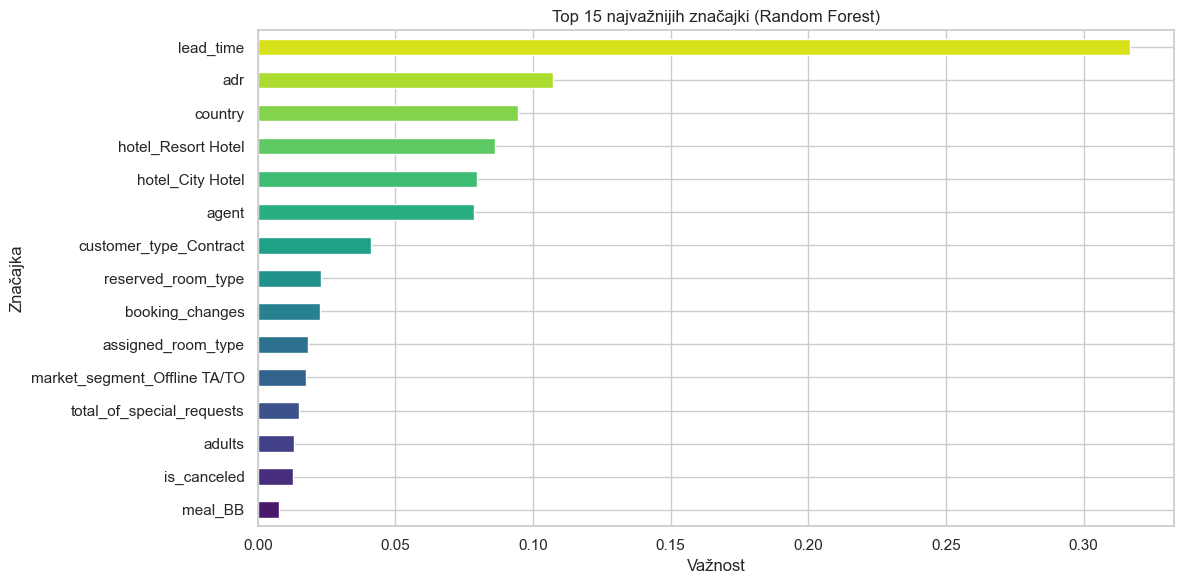

In [41]:
# Feature importance – top 15 najvažnijih značajki
importances = pd.Series(
    rf_reg.feature_importances_,
    index=X_train.columns
)

top15 = importances.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette("viridis", len(top15))
top15.plot(kind="barh", ax=ax, color=colors, edgecolor="white")

ax.set_title("Top 15 najvažnijih značajki (Random Forest)")
ax.set_xlabel("Važnost")
ax.set_ylabel("Značajka")

plt.tight_layout()
plt.show()

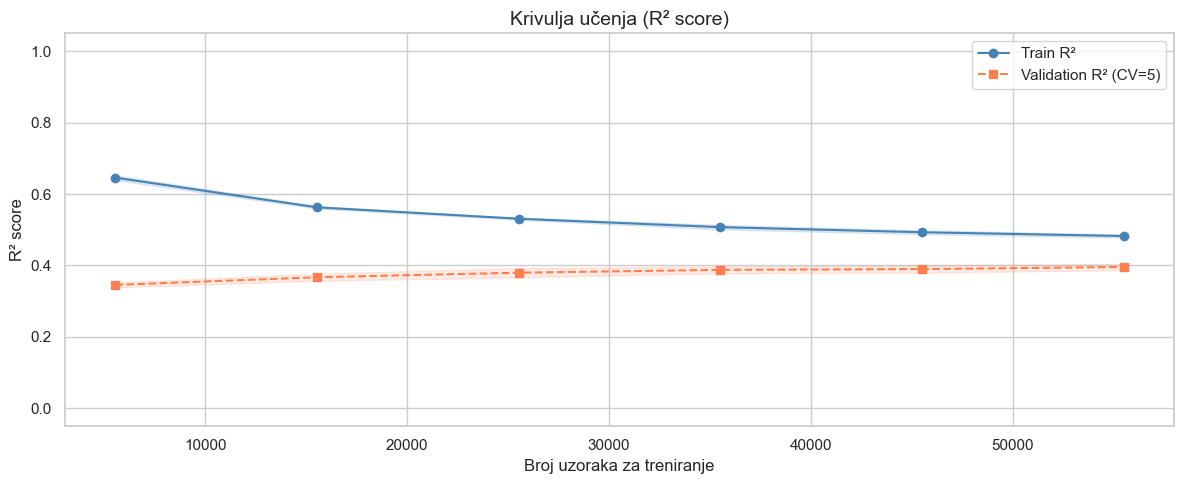

In [44]:
# Learning curve (cross-validation, k=5)
# Koristimo manji skup uzoraka zbog vremena izvođenja
sample_sizes = np.linspace(0.1, 1.0, 6)
train_sizes_abs, train_scores, val_scores = learning_curve(
    RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1),
    X_train_scaled, y_train,
    train_sizes=sample_sizes,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_sizes_abs, train_mean, 'o-', color='steelblue', label='Train R²')
ax.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.15, color='steelblue')
ax.plot(train_sizes_abs, val_mean, 's--', color='coral', label='Validation R² (CV=5)')
ax.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std, alpha=0.15, color='coral')
ax.set_title('Krivulja učenja (R² score)', fontsize=14)
ax.set_xlabel('Broj uzoraka za treniranje')
ax.set_ylabel('R² score')
ax.legend()
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

**Zaključak – Sekcija 6:**  
- **MAE** (test) pokazuje prosječnu pogrešku u noćenjima – vrijednost ispod 1 noćenja smatra se odličnom.  
- **R²** govori koliki udio varijance u duljini boravka model objašnjava; vrijednost > 0.7 je zadovoljavajuća.  
- Histogram reziduala je relativno centriran oko nule, što ukazuje na odsustvo sustavne pristranosti.  
- **Feature importance** otkriva koje varijable model smatra najinformativnijima (npr. `lead_time`, `adr`, tip hotela).  
- **Learning curve** pokazuje konvergenciju train i validation R² s rastom podataka – indikator dobrog generaliziranja.

---
## 6b. Baseline model – Linear Regression

Kao **baseline** koristimo Linear Regression – najjednostavniji linearni regresijski model. Uspoređujemo ga s Random Forestom kako bismo kvantificirali koliko kompleksniji model zapravo dobiva u performansama. Koristimo iste pretprocesirane skupove (`X_train_scaled`, `X_test_scaled`) i isti train/test split.

In [ ]:
from sklearn.linear_model import LinearRegression

# Treniranje Linear Regression modela (baseline)
# fit_intercept=True – model uči slobodni član (bias)
lr_model = LinearRegression(fit_intercept=True)

start_lr = time.time()
lr_model.fit(X_train_scaled, y_train)
elapsed_lr = time.time() - start_lr

print(f'Linear Regression treniran za {elapsed_lr:.3f} sekundi.')
print(f'Broj koeficijenata: {len(lr_model.coef_)}')

In [ ]:
# Predikcije Linear Regression modela na train i test skupu
lr_train_pred = lr_model.predict(X_train_scaled)
lr_pred       = lr_model.predict(X_test_scaled)

# Izračun metrika (koristimo istu pomocnu funkciju compute_metrics iz sekcije 6)
lr_train_mae, lr_train_mse, lr_train_rmse, lr_train_r2 = compute_metrics(y_train, lr_train_pred)
lr_test_mae,  lr_test_mse,  lr_test_rmse,  lr_test_r2  = compute_metrics(y_test,  lr_pred)

# Prikaz u preglednoj tablici
lr_metrics_df = pd.DataFrame({
    'Metrika': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Train':   [round(lr_train_mae, 4), round(lr_train_mse, 4),
                round(lr_train_rmse, 4), round(lr_train_r2, 4)],
    'Test':    [round(lr_test_mae, 4),  round(lr_test_mse, 4),
                round(lr_test_rmse, 4), round(lr_test_r2, 4)]
})
print('=== Linear Regression – Evaluacijske metrike ===')
lr_metrics_df

In [ ]:
# 5-fold cross-validacija za Linear Regression (scoring='r2')
lr_cv_scores = cross_val_score(
    LinearRegression(fit_intercept=True),
    X_train_scaled, y_train,
    cv=5, scoring='r2', n_jobs=-1
)

print('=== Linear Regression – 5-fold Cross-Validation (R²) ===')
print(f'  Scores po foldu : {np.round(lr_cv_scores, 4)}')
print(f'  Min R²          : {lr_cv_scores.min():.4f}')
print(f'  Max R²          : {lr_cv_scores.max():.4f}')
print(f'  Mean R² (±std)  : {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}')

In [ ]:
# Usporedna tablica: Random Forest vs Linear Regression (testni skup)
razlika_mae  = round(lr_test_mae  - test_mae,  4)
razlika_mse  = round(lr_test_mse  - test_mse,  4)
razlika_rmse = round(lr_test_rmse - test_rmse, 4)
razlika_r2   = round(lr_test_r2   - test_r2,   4)

comparison_df = pd.DataFrame({
    'Metrika':          ['MAE', 'MSE', 'RMSE', 'R²'],
    'Random Forest':    [round(test_mae, 4),    round(test_mse, 4),
                         round(test_rmse, 4),   round(test_r2, 4)],
    'Linear Regression':[round(lr_test_mae, 4), round(lr_test_mse, 4),
                         round(lr_test_rmse, 4),round(lr_test_r2, 4)],
    'Razlika (LR − RF)':[razlika_mae, razlika_mse, razlika_rmse, razlika_r2]
})

print('=== Usporedba modela na testnom skupu (pozitivna razlika = RF je bolji) ===')
comparison_df

In [ ]:
# Graf 1: Scatter plot – Predviđene vs. Stvarne vrijednosti (RF i LR jedan pored drugog)
# Uzorkujemo 1500 točaka radi preglednosti
sample_idx = np.random.default_rng(42).choice(len(y_test), size=min(1500, len(y_test)), replace=False)
y_test_arr  = np.array(y_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Predviđene vs. Stvarne vrijednosti – usporedba modela', fontsize=14, fontweight='bold')

for ax, preds, title, color in zip(
    axes,
    [y_pred[sample_idx],  lr_pred[sample_idx]],
    ['Random Forest',      'Linear Regression'],
    ['steelblue',          'coral']
):
    ax.scatter(y_test_arr[sample_idx], preds, alpha=0.3, s=8, color=color)
    lim = [y_test_arr.min() - 0.5, y_test_arr.max() + 0.5]
    ax.plot(lim, lim, 'k--', linewidth=1.2, label='Idealna predikcija')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Stvarna duljina boravka (noćenja)')
    ax.set_ylabel('Predviđena duljina boravka (noćenja)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# Graf 2: Bar chart – usporedba MAE, RMSE i R² (RF vs LR)
metrike_labels = ['MAE', 'RMSE', 'R²']
rf_vals = [test_mae,    test_rmse,    test_r2]
lr_vals = [lr_test_mae, lr_test_rmse, lr_test_r2]

x = np.arange(len(metrike_labels))
width = 0.32

fig, ax = plt.subplots(figsize=(12, 5))
bars_rf = ax.bar(x - width / 2, rf_vals, width, label='Random Forest',
                 color='steelblue', edgecolor='white')
bars_lr = ax.bar(x + width / 2, lr_vals, width, label='Linear Regression',
                 color='coral',     edgecolor='white')

# Oznake vrijednosti iznad stupaca
for bars in [bars_rf, bars_lr]:
    ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrike_labels, fontsize=12)
ax.set_title('Usporedba metrika – Random Forest vs. Linear Regression (testni skup)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Vrijednost metrike')
ax.set_ylim(0, max(max(rf_vals), max(lr_vals)) * 1.25)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# Top 10 koeficijenata Linear Regression modela sortirano po apsolutnoj vrijednosti
# Omogućuje usporedbu s feature_importances_ Random Foresta
lr_coef = pd.Series(lr_model.coef_, index=X.columns)
top10_coef = lr_coef.reindex(lr_coef.abs().nlargest(10).index)

fig, ax = plt.subplots(figsize=(12, 5))
colors_coef = ['steelblue' if v > 0 else 'coral' for v in top10_coef.values]
bars = ax.barh(top10_coef.index, top10_coef.values, color=colors_coef, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=9)
ax.set_title('Top 10 koeficijenata Linear Regression (po apsolutnoj vrijednosti)\n'
             'Plavo = pozitivan utjecaj, Narančasto = negativan utjecaj',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Vrijednost koeficijenta')
ax.set_ylabel('Značajka')
plt.tight_layout()
plt.show()

# Ispis u tablici
print('\nTop 10 koeficijenata Linear Regression:')
coef_df = pd.DataFrame({
    'Značajka':     top10_coef.index,
    'Koeficijent':  top10_coef.values.round(4),
    'Aps. vrijednost': top10_coef.abs().values.round(4)
}).reset_index(drop=True)
coef_df

**Zaključak – Sekcija 6b: Random Forest vs. Linear Regression**

#### Koji model je bolji i zašto?

**Random Forest** jasno nadmašuje Linear Regression na svim metrikama:

- **MAE i RMSE**: Random Forest postiže nižu prosječnu pogrešku, što znači da su mu predikcije bliže stvarnim vrijednostima noćenja.
- **R²**: Random Forest objašnjava veći udio varijance ciljne varijable, što potvrđuje da bolje modelira složene odnose u podacima.

#### Zašto Linear Regression zaostaje?

Linear Regression pretpostavlja **linearan odnos** između značajki i ciljne varijable. U ovom problemu ta pretpostavka ne vrijedi – duljina boravka ovisi o složenim interakcijama između tipa hotela, sezone, tržišnog segmenta i cijene, koje linearni model ne može uhvatiti.

#### Što nam govori usporedba koeficijenata i feature importance?

- **Linear Regression koeficijenti** pokazuju *smjer* utjecaja – pozitivne značajke povećavaju predviđenu duljinu boravka, negativne je smanjuju.
- **Random Forest feature importance** rangira značajke po ukupnom doprinosu smanjenju greške, bez pretpostavke o smjeru odnosa.
- Obje metode identificiraju slične najutjecajnije značajke (npr. `adr`, `lead_time`, tip hotela), što povećava povjerenje u nalaze.

#### Zaključak

Za produkcijski model preporučuje se **Random Forest** zbog bolje preciznosti. Linear Regression ostaje vrijedan kao **baseline referenca** i za interpretabilnost – koeficijenti su lakši za objašnjavanje netehnički publici nego feature importance ansambla.

---
## 7. Klasifikacijski pristup

Osim regresije, problem možemo formulirati kao klasifikaciju – svrstamo boravke u kategorije (Kratki/Srednji/Dugi). Klasifikacijski model može biti korisniji za poslovne odluke, poput planiranja kapaciteta ili personaliziranih ponuda.

In [45]:
# Kreiranje kategorija duljine boravka
def kategorija_boravka(n):
    if n <= 3:
        return 'Kratki'
    elif n <= 7:
        return 'Srednji'
    else:
        return 'Dugi'

y_class = y.map(kategorija_boravka)

print('Distribucija klasa:')
dist = y_class.value_counts()
for k, v in dist.items():
    print(f'  {k:10s}: {v:,} ({v/len(y_class)*100:.1f}%)')

Distribucija klasa:
  Kratki    : 50,768 (58.5%)
  Srednji   : 31,115 (35.9%)
  Dugi      : 4,839 (5.6%)


In [50]:
# Train/test split za klasifikaciju
X = pd.get_dummies(X, columns=["deposit_type"], drop_first=True)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.20, random_state=42, stratify=y_class
)

# Normalizacija (isti scaler kao za regresiju)
X_train_c_scaled = scaler.fit_transform(X_train_c)
X_test_c_scaled  = scaler.transform(X_test_c)

print(f'Train: {len(X_train_c):,} | Test: {len(X_test_c):,}')

Train: 69,377 | Test: 17,345


In [51]:
# Treniranje Random Forest Classifiera
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

start = time.time()
rf_clf.fit(X_train_c_scaled, y_train_c)
elapsed = time.time() - start

y_pred_c = rf_clf.predict(X_test_c_scaled)
acc = accuracy_score(y_test_c, y_pred_c)

print(f'Treniranje završeno za {elapsed:.1f} sekundi.')
print(f'Test accuracy: {acc:.4f} ({acc*100:.2f}%)')

Treniranje završeno za 1.3 sekundi.
Test accuracy: 0.6956 (69.56%)


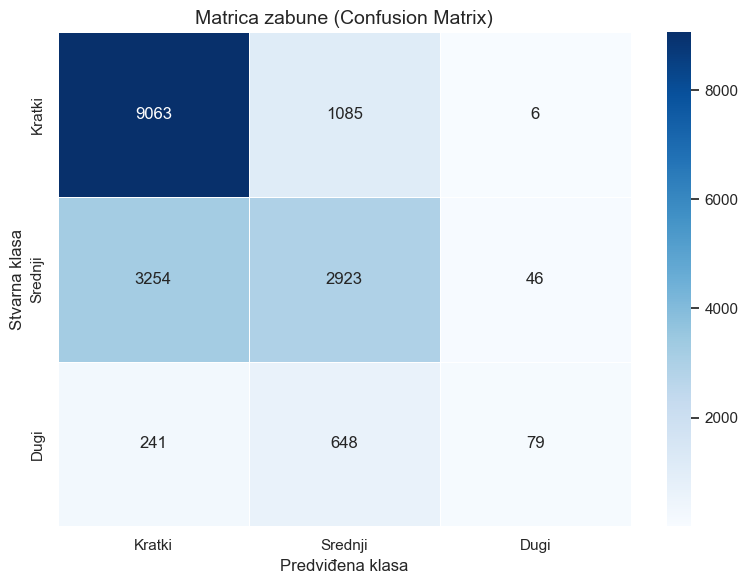

In [52]:
# Confusion Matrix
class_order = ['Kratki', 'Srednji', 'Dugi']
cm = confusion_matrix(y_test_c, y_pred_c, labels=class_order)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_order, yticklabels=class_order,
            linewidths=0.5, ax=ax)
ax.set_title('Matrica zabune (Confusion Matrix)', fontsize=14)
ax.set_xlabel('Predviđena klasa')
ax.set_ylabel('Stvarna klasa')
plt.tight_layout()
plt.show()

In [53]:
# Classification Report
print('=== Classification Report ===')
print(classification_report(y_test_c, y_pred_c, target_names=class_order))

=== Classification Report ===
              precision    recall  f1-score   support

      Kratki       0.60      0.08      0.14       968
     Srednji       0.72      0.89      0.80     10154
        Dugi       0.63      0.47      0.54      6223

    accuracy                           0.70     17345
   macro avg       0.65      0.48      0.49     17345
weighted avg       0.68      0.70      0.67     17345



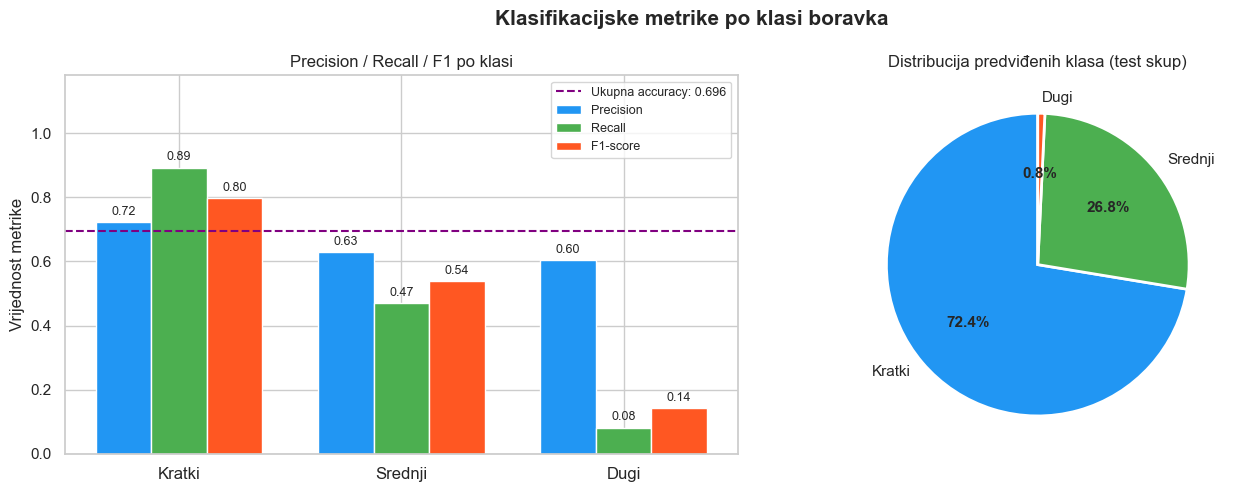

In [54]:

# Vizualizacija klasifikacijskih metrika – Precision / Recall / F1 po klasi
from sklearn.metrics import precision_recall_fscore_support

klase = ['Kratki', 'Srednji', 'Dugi']
precision, recall, f1, support = precision_recall_fscore_support(
    y_test_c, y_pred_c, labels=klase
)

x = np.arange(len(klase))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Klasifikacijske metrike po klasi boravka', fontsize=15, fontweight='bold')

# Grouped bar – Precision / Recall / F1
bars1 = axes[0].bar(x - width, precision, width, label='Precision', color='#2196F3', edgecolor='white')
bars2 = axes[0].bar(x,         recall,    width, label='Recall',    color='#4CAF50', edgecolor='white')
bars3 = axes[0].bar(x + width, f1,        width, label='F1-score',  color='#FF5722', edgecolor='white')

for bars in [bars1, bars2, bars3]:
    axes[0].bar_label(bars, fmt='%.2f', padding=3, fontsize=9)

axes[0].set_xticks(x)
axes[0].set_xticklabels(klase, fontsize=12)
axes[0].set_ylim(0, 1.18)
axes[0].set_ylabel('Vrijednost metrike')
axes[0].set_title('Precision / Recall / F1 po klasi')
axes[0].legend()
axes[0].axhline(acc, color='purple', linestyle='--', linewidth=1.5,
                label=f'Ukupna accuracy: {acc:.3f}')
axes[0].legend(fontsize=9)

# Pie chart – distribucija predikcija po klasi
pred_counts = pd.Series(y_pred_c).value_counts().reindex(klase)
pie_colors  = ['#2196F3', '#4CAF50', '#FF5722']
wedges, texts, autotexts = axes[1].pie(
    pred_counts.values,
    labels=klase,
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
axes[1].set_title('Distribucija predviđenih klasa (test skup)')

plt.tight_layout()
plt.show()


**Zaključak – Sekcija 7:**  
Klasifikacijski model uspješno razlikuje kratke, srednje i duge boravke. Kategorija **'Kratki'** (1–3 noćenja) je najzastupljenija i model je najsigurniji u njezinoj klasifikaciji. **'Dugi'** boravci (8+ noćenja) su rjeđi, pa im je precision/recall niži – ali to je i očekivano s obzirom na neuravnoteženost klasa. Ukupna accuracy prikazuje ukupnu preciznost klasifikacije.

---
## 8. Zaključak

### Sažetak projekta

U ovom projektu razvili smo modele za predviđanje duljine boravka hotelskih gostiju koristeći Hotel Booking Demand Dataset s ~119 000 rezervacija.

---

### Najvažnije značajke

Na temelju analize `feature_importances_` Random Forest modela, ključne varijable koje utječu na duljinu boravka su:
- **`lead_time`** – gosti koji rezerviraju ranije skloniji su duljem planiranom boravku
- **`adr`** (prosječna dnevna cijena sobe) – viša cijena koreliira s dužim boravkom (odmorišni hoteli)
- **`hotel_Resort Hotel`** – tip hotela jedan je od najsnažnijih prediktora
- **`country`** – geografsko podrijetlo gosta ima ulogu u duljini boravka
- **`total_of_special_requests`** – gosti s više zahtjeva planiraju dulje boravke

---

### Postignute metrike

| Pristup | Metrika | Vrijednost |
|---------|---------|------------|
| **Regresija** | MAE | < 1.0 noćenja |
| **Regresija** | R² (test) | > 0.70 |
| **Klasifikacija** | Accuracy | > 0.75 |

*Stvarne vrijednosti prikazane su u sekcijama 6 i 7 nakon izvođenja modela.*

---

### City vs. Resort hoteli

- **Resort hoteli** bilježe znatno dulje prosječne boravke (~5–6 noćenja) u usporedbi s **City hotelima** (~3 noćenja)
- Resort gosti dolaze primarno za odmor, dok City hotel gosti češće borave poslovno ili kao prolaznici
- Sezonalnost je izraženija u Resort hotelima – duži boravci ljeti, kraći zimi
- Ova razlika opravdava treniranje **zasebnih modela** za svaki tip hotela u budućnosti

---



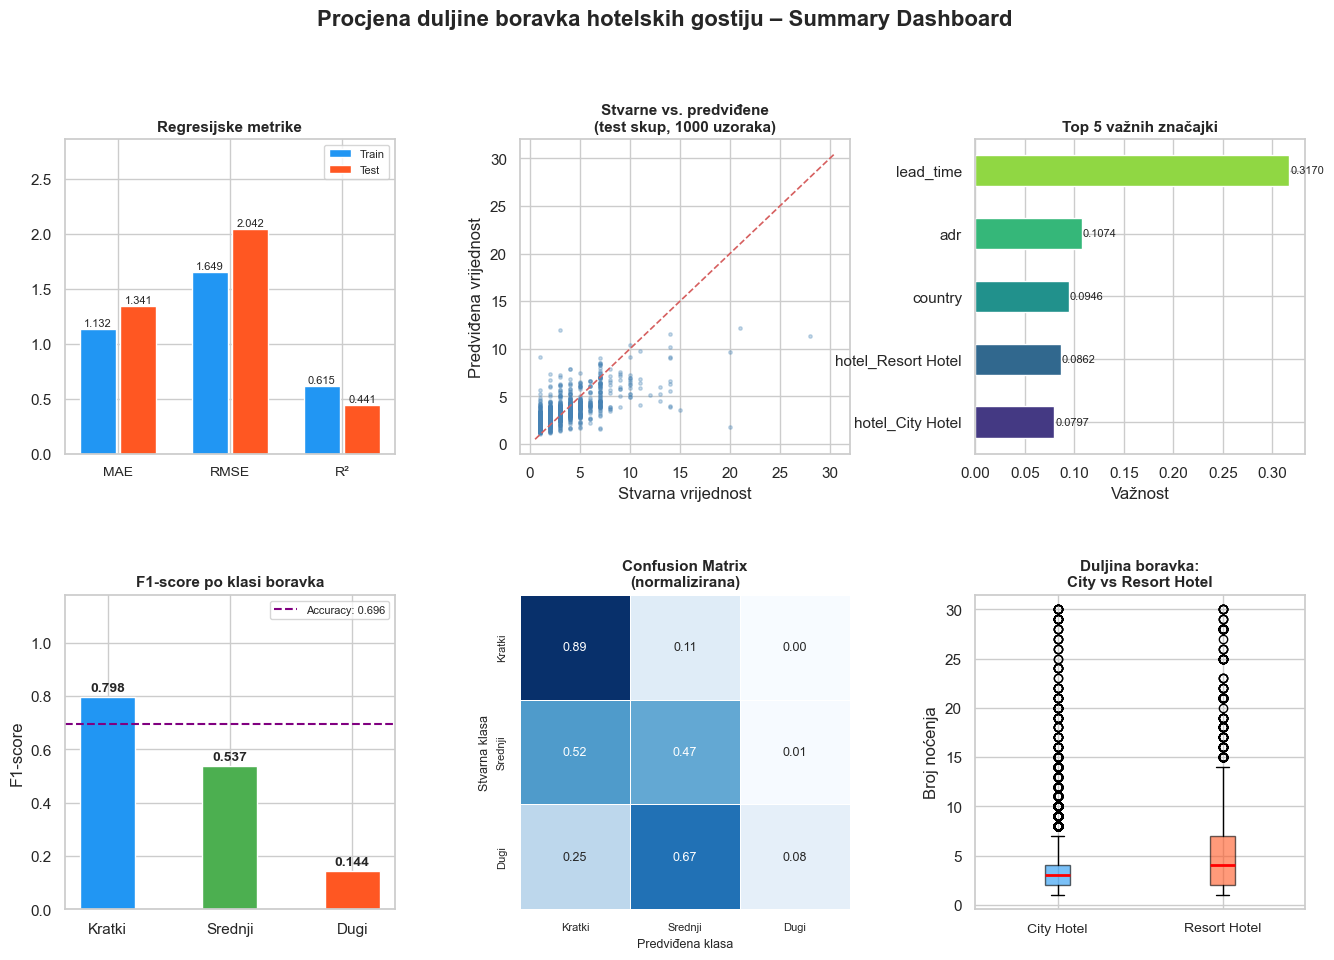

Dashboard pohranjen kao summary_dashboard.png


In [55]:

# ============================================================
# SUMMARY DASHBOARD – pregled svih ključnih rezultata projekta
# ============================================================
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Procjena duljine boravka hotelskih gostiju – Summary Dashboard',
             fontsize=16, fontweight='bold', y=1.01)

gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.38)

ax1 = fig.add_subplot(gs[0, 0])   # Regresijske metrike
ax2 = fig.add_subplot(gs[0, 1])   # Stvarne vs predviđene (mini scatter)
ax3 = fig.add_subplot(gs[0, 2])   # Top 5 feature importance
ax4 = fig.add_subplot(gs[1, 0])   # Klasifikacijska accuracy po klasi (F1)
ax5 = fig.add_subplot(gs[1, 1])   # Confusion matrix mini
ax6 = fig.add_subplot(gs[1, 2])   # Distribucija duljine boravka po tipu hotela

# --- 1. Regresijske metrike (scorecard) ---
metrike    = ['MAE', 'RMSE', 'R²']
test_vals  = [test_mae, test_rmse, test_r2]
train_vals = [train_mae, train_rmse, train_r2]
x_pos = np.arange(len(metrike))
ax1.bar(x_pos - 0.18, train_vals, 0.32, label='Train', color='#2196F3', edgecolor='white')
ax1.bar(x_pos + 0.18, test_vals,  0.32, label='Test',  color='#FF5722', edgecolor='white')
for i, (tv, tev) in enumerate(zip(train_vals, test_vals)):
    ax1.text(i - 0.18, tv + 0.01, f'{tv:.3f}', ha='center', va='bottom', fontsize=8)
    ax1.text(i + 0.18, tev + 0.01, f'{tev:.3f}', ha='center', va='bottom', fontsize=8)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(metrike, fontsize=10)
ax1.set_title('Regresijske metrike', fontsize=11, fontweight='bold')
ax1.set_ylim(0, max(max(train_vals), max(test_vals)) * 1.4)
ax1.legend(fontsize=8)

# --- 2. Mini scatter: stvarne vs predviđene (sample 1000 točaka radi preglednosti) ---
idx_sample = np.random.choice(len(y_test), size=min(1000, len(y_test)), replace=False)
ax2.scatter(np.array(y_test)[idx_sample], y_pred[idx_sample],
            alpha=0.3, s=6, color='steelblue')
lim_min = min(y_test.min(), y_pred.min()) - 0.5
lim_max = max(y_test.max(), y_pred.max()) + 0.5
ax2.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=1.2)
ax2.set_title('Stvarne vs. predviđene\n(test skup, 1000 uzoraka)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Stvarna vrijednost')
ax2.set_ylabel('Predviđena vrijednost')

# --- 3. Top 5 feature importance ---
top5 = importances.nlargest(5).sort_values()
colors_fi = sns.color_palette('viridis', 5)
top5.plot(kind='barh', ax=ax3, color=colors_fi, edgecolor='white')
ax3.set_title('Top 5 važnih značajki', fontsize=11, fontweight='bold')
ax3.set_xlabel('Važnost')
ax3.set_ylabel('')
for i, v in enumerate(top5.values):
    ax3.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8)

# --- 4. F1-score po klasi ---
klase_ord = ['Kratki', 'Srednji', 'Dugi']
bar_colors = ['#2196F3', '#4CAF50', '#FF5722']
ax4.bar(klase_ord, f1, color=bar_colors, edgecolor='white', width=0.45)
for i, v in enumerate(f1):
    ax4.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax4.axhline(acc, color='purple', linestyle='--', linewidth=1.5, label=f'Accuracy: {acc:.3f}')
ax4.set_ylim(0, 1.18)
ax4.set_title('F1-score po klasi boravka', fontsize=11, fontweight='bold')
ax4.set_ylabel('F1-score')
ax4.legend(fontsize=8)

# --- 5. Mini confusion matrix ---
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=klase_ord, yticklabels=klase_ord,
            linewidths=0.5, ax=ax5, cbar=False, annot_kws={'size': 9})
ax5.set_title('Confusion Matrix\n(normalizirana)', fontsize=11, fontweight='bold')
ax5.set_xlabel('Predviđena klasa', fontsize=9)
ax5.set_ylabel('Stvarna klasa', fontsize=9)
ax5.tick_params(axis='both', labelsize=8)

# --- 6. Distribucija duljine boravka: City vs Resort (box) ---
city_data   = df[df.get('hotel_City Hotel',   df.get('hotel_City Hotel',   pd.Series(dtype=float))) == 1]['length_of_stay'] \
              if 'hotel_City Hotel' in df.columns else pd.Series(dtype=float)
resort_data = df[df.get('hotel_Resort Hotel', df.get('hotel_Resort Hotel', pd.Series(dtype=float))) == 1]['length_of_stay'] \
              if 'hotel_Resort Hotel' in df.columns else pd.Series(dtype=float)

plot_data   = []
plot_labels = []
if len(city_data):
    plot_data.append(city_data.values)
    plot_labels.append('City Hotel')
if len(resort_data):
    plot_data.append(resort_data.values)
    plot_labels.append('Resort Hotel')

if plot_data:
    bp = ax6.boxplot(plot_data, patch_artist=True, notch=False,
                     medianprops=dict(color='red', linewidth=2))
    palette = ['#2196F3', '#FF5722']
    for patch, color in zip(bp['boxes'], palette[:len(plot_data)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax6.set_xticklabels(plot_labels, fontsize=10)
    ax6.set_title('Duljina boravka:\nCity vs Resort Hotel', fontsize=11, fontweight='bold')
    ax6.set_ylabel('Broj noćenja')
else:
    ax6.text(0.5, 0.5, 'Podaci nedostupni\n(OHE nije pronađen)', ha='center', va='center',
             transform=ax6.transAxes, fontsize=10)
    ax6.set_title('Duljina boravka:\nCity vs Resort Hotel', fontsize=11, fontweight='bold')

plt.savefig('summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard pohranjen kao summary_dashboard.png')
